# 第 3 章　笛卡尔张量的变换、分解与不变量：计算伴侣

本 Notebook 是《张量分析》第 3 章的配套电子资源。它不复制纸质教材全文，而是围绕“**坐标变换—分量变化—主方向—谱分解—不变量**”建立可执行的计算实验。

本章统一采用教材中的被动坐标变换约定：

$$
\mathbf e'_i=Q_{ij}\mathbf e_j,
\qquad
\mathbf v'=\mathbf Q\mathbf v,
$$

$$
T'_{ij}=Q_{ik}Q_{j\ell}T_{k\ell},
\qquad
\mathbf T'=\mathbf Q\mathbf T\mathbf Q^{\mathsf T}.
$$

> **代码约定**
>
> - 数学指标 $1,2,3$ 对应 Python 下标 `0,1,2`；
> - 张量缩并和分量变换优先使用显式 `for` 循环；
> - 不使用 `@` 和 `np.einsum`；
> - `numpy.linalg` 主要用于特征值、行列式和 QR 分解等数值工具；
> - Markdown 数学公式只使用 `$...$` 与 `$$...$$`。

## 学习目标

完成本 Notebook 后，应能够：

1. 构造方向余弦矩阵并检验正交性；
2. 区分被动坐标变换与主动旋转；
3. 用显式循环完成二阶与四阶张量的坐标变换；
4. 核对平面应力解析变换并求主方向；
5. 构造法向与切向投影算子；
6. 计算双点积、对称—反对称分解及轴矢量；
7. 对实对称张量完成主值、主方向、右手主基底与谱重构；
8. 计算 $I_1,I_2,I_3$ 并验证旋转不变性；
9. 完成球—偏分解、$J_2$ 与 von Mises 等效应力计算；
10. 验证四阶各向同性弹性张量的旋转不变性；
11. 理解重复或近重复特征值下主方向与特征子空间的区别；
12. 用结构张量说明“坐标不变性”与“材料各向同性”不是同一概念。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=8, suppress=True)
rng = np.random.default_rng(20260823)

print('NumPy version:', np.__version__)

NumPy version: 2.3.5


## 1. 基础工具：把指标式翻译成显式循环

后续反复使用

$$
y_i=A_{ij}x_j,
$$

以及

$$
T'_{ij}=Q_{ik}Q_{j\ell}T_{k\ell}.
$$

自由指标决定输出位置，哑指标负责内部求和。

In [2]:
def matvec_loop(A, x):
    A = np.asarray(A, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.zeros(A.shape[0])
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            y[i] += A[i, j] * x[j]
    return y


def matrix_product_loop(A, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.zeros((A.shape[0], B.shape[1]))
    for i in range(A.shape[0]):
        for k in range(B.shape[1]):
            for j in range(A.shape[1]):
                C[i, k] += A[i, j] * B[j, k]
    return C


def transform_second_order(T, Q):
    T = np.asarray(T, dtype=float)
    Q = np.asarray(Q, dtype=float)
    n = Q.shape[0]
    out = np.zeros_like(T, dtype=float)
    for i in range(n):
        for j in range(n):
            for k in range(n):
                for ell in range(n):
                    out[i, j] += Q[i, k] * Q[j, ell] * T[k, ell]
    return out


def double_dot_loop(A, B):
    value = 0.0
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            value += A[i, j] * B[i, j]
    return value

## 2. 数字赋能 03-A：方向余弦矩阵

新坐标系绕 $+\mathbf e_3$ 方向逆时针旋转 $\theta$ 时，教材定义

$$
\mathbf Q=
\begin{bmatrix}
\cos\theta&\sin\theta&0\\
-\sin\theta&\cos\theta&0\\
0&0&1
\end{bmatrix}.
$$

应满足

$$
\mathbf Q\mathbf Q^{\mathsf T}=\mathbf I,
\qquad
\det\mathbf Q=1.
$$

In [3]:
theta = np.radians(30.0)
c, s = np.cos(theta), np.sin(theta)
Q = np.array([
    [ c,  s, 0.0],
    [-s,  c, 0.0],
    [0.0, 0.0, 1.0],
])

QQT = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        for k in range(3):
            QQT[i, j] += Q[i, k] * Q[j, k]

print('Q =\n', Q)
print('Q Q^T =\n', QQT)
print('det(Q) =', np.linalg.det(Q))
assert np.allclose(QQT, np.eye(3))
assert np.isclose(np.linalg.det(Q), 1.0)

Q =
 [[ 0.8660254  0.5        0.       ]
 [-0.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]
Q Q^T =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
det(Q) = 1.0


沿用第一章的来流速度

$$
\mathbf v=(20,15,0)^{\mathsf T}\ \mathrm{m/s},
$$

计算 $\mathbf v'=\mathbf Q\mathbf v$ 并验证模长不变。

In [4]:
v = np.array([20.0, 15.0, 0.0])
v_prime = matvec_loop(Q, v)
print("v' =", v_prime)
print('|v| =', np.linalg.norm(v))
print("|v'| =", np.linalg.norm(v_prime))
assert np.allclose(v_prime[:2], [24.82050808, 2.99038106])
assert np.isclose(np.linalg.norm(v), np.linalg.norm(v_prime))

v' = [24.82050808  2.99038106  0.        ]
|v| = 25.0
|v'| = 25.000000000000004


## 3. 被动坐标变换与主动旋转

对同一个几何转角，教材强调

$$
\mathbf Q=\mathbf R^{\mathsf T}.
$$

$\mathbf Q$ 描述基底旋转而物理矢量不动；$\mathbf R$ 描述固定基底中的物理矢量主动旋转。

In [5]:
R = np.array([
    [c, -s, 0.0],
    [s,  c, 0.0],
    [0.0, 0.0, 1.0],
])

v_active = matvec_loop(R, v)
v_passive = matvec_loop(Q, v)

print('Q = R^T:', np.allclose(Q, R.T))
print('active result =', v_active)
print('passive result =', v_passive)
assert np.allclose(Q, R.T)
assert np.isclose(np.linalg.norm(v_active), np.linalg.norm(v))
assert np.isclose(np.linalg.norm(v_passive), np.linalg.norm(v))
assert not np.allclose(v_active, v_passive)

Q = R^T: True
active result = [ 9.82050808 22.99038106  0.        ]
passive result = [24.82050808  2.99038106  0.        ]


## 4. 数字赋能 03-B：平面应力解析变换

教材例题取

$$
\boldsymbol\sigma=
\begin{bmatrix}
200&50\\
50&0
\end{bmatrix}\ \mathrm{MPa},
$$

材料轴相对全局轴顺时针 $15^\circ$，故被动转角为 $\theta=-15^\circ$。

In [6]:
sigma2 = np.array([[200.0, 50.0], [50.0, 0.0]])
theta2 = np.radians(-15.0)
c2, s2 = np.cos(theta2), np.sin(theta2)
Q2 = np.array([[c2, s2], [-s2, c2]])

sigma2_prime = transform_second_order(sigma2, Q2)
print("sigma' =\n", np.round(sigma2_prime, 6))

expected = np.array([
    [161.60254038, 93.30127019],
    [ 93.30127019, 38.39745962],
])
assert np.allclose(sigma2_prime, expected)

sigma' =
 [[161.60254  93.30127]
 [ 93.30127  38.39746]]


解析公式为

$$
\sigma'_{11}=\frac{\sigma_{11}+\sigma_{22}}2
+\frac{\sigma_{11}-\sigma_{22}}2\cos2\theta
+\tau_{12}\sin2\theta,
$$

$$
\tau'_{12}=-\frac{\sigma_{11}-\sigma_{22}}2\sin2\theta
+\tau_{12}\cos2\theta.
$$

下面独立核验显式循环结果，并检查迹和行列式不变。

In [7]:
sigma11, sigma22, tau12 = sigma2[0,0], sigma2[1,1], sigma2[0,1]

sigma11_c = 0.5*(sigma11+sigma22) + 0.5*(sigma11-sigma22)*np.cos(2*theta2) + tau12*np.sin(2*theta2)
sigma22_c = 0.5*(sigma11+sigma22) - 0.5*(sigma11-sigma22)*np.cos(2*theta2) - tau12*np.sin(2*theta2)
tau12_c = -0.5*(sigma11-sigma22)*np.sin(2*theta2) + tau12*np.cos(2*theta2)
closed = np.array([[sigma11_c, tau12_c], [tau12_c, sigma22_c]])

print('loop/closed:', np.allclose(sigma2_prime, closed))
print('trace invariant:', np.isclose(np.trace(sigma2), np.trace(sigma2_prime)))
print('det invariant:', np.isclose(np.linalg.det(sigma2), np.linalg.det(sigma2_prime)))
assert np.allclose(sigma2_prime, closed)
assert np.isclose(np.trace(sigma2), np.trace(sigma2_prime))
assert np.isclose(np.linalg.det(sigma2), np.linalg.det(sigma2_prime))

loop/closed: True
trace invariant: True
det invariant: True


### 双角结构与主方向

连续扫描 $\theta$，观察三个平面应力分量的周期变化。二阶张量变换包含两个方向余弦因子，因此出现 $2\theta$。

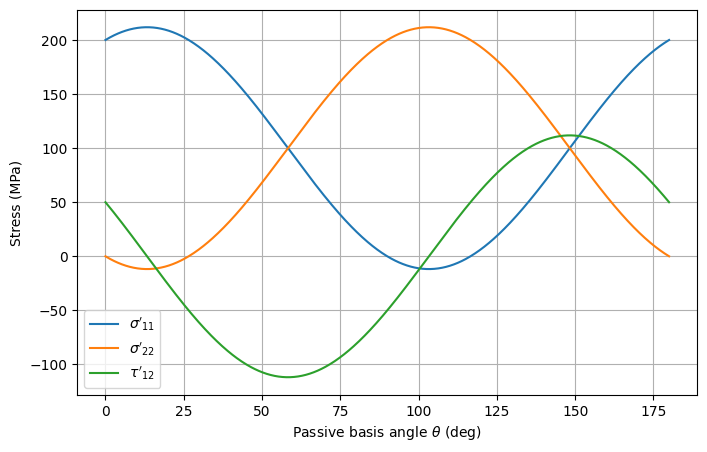

In [8]:
theta_deg = np.linspace(0.0, 180.0, 721)
s11_curve = np.zeros(theta_deg.size)
s22_curve = np.zeros(theta_deg.size)
t12_curve = np.zeros(theta_deg.size)

for p, deg in enumerate(theta_deg):
    ang = np.radians(deg)
    s11_curve[p] = 0.5*(sigma11+sigma22) + 0.5*(sigma11-sigma22)*np.cos(2*ang) + tau12*np.sin(2*ang)
    s22_curve[p] = 0.5*(sigma11+sigma22) - 0.5*(sigma11-sigma22)*np.cos(2*ang) - tau12*np.sin(2*ang)
    t12_curve[p] = -0.5*(sigma11-sigma22)*np.sin(2*ang) + tau12*np.cos(2*ang)

plt.figure(figsize=(8,5))
plt.plot(theta_deg, s11_curve, label=r"$\sigma'_{11}$")
plt.plot(theta_deg, s22_curve, label=r"$\sigma'_{22}$")
plt.plot(theta_deg, t12_curve, label=r"$\tau'_{12}$")
plt.xlabel(r"Passive basis angle $\theta$ (deg)")
plt.ylabel('Stress (MPa)')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
theta_p = 0.5*np.arctan2(2.0*tau12, sigma11-sigma22)
Qp = np.array([
    [ np.cos(theta_p), np.sin(theta_p)],
    [-np.sin(theta_p), np.cos(theta_p)],
])
sigma_principal_2d = transform_second_order(sigma2, Qp)
print('principal angle =', np.degrees(theta_p), 'deg')
print('principal stress matrix =\n', np.round(sigma_principal_2d, 10))
assert abs(sigma_principal_2d[0,1]) < 1e-10
assert abs(sigma_principal_2d[1,0]) < 1e-10

principal angle = 13.282525588538995 deg
principal stress matrix =
 [[211.80339887  -0.        ]
 [  0.         -11.80339887]]


## 5. 二阶张量构造与投影算子

由两个矢量构造

$$
T_{ij}=u_iv_j.
$$

若 $\mathbf n$ 为单位矢量，则

$$
(\mathbf P_n)_{ij}=n_in_j,
\qquad
\mathbf P_t=\mathbf I-\mathbf P_n.
$$

应满足幂等性与互补性。

In [10]:
u3 = np.array([2.0, -1.0, 3.0])
v3 = np.array([0.5, 4.0, 1.0])
T_dyad = np.zeros((3,3))
for i in range(3):
    for j in range(3):
        T_dyad[i,j] = u3[i]*v3[j]
print('u v^T =\n', T_dyad)

n = np.array([2.0,-1.0,2.0])
n = n/np.linalg.norm(n)
Pn = np.zeros((3,3)); Pt = np.zeros((3,3))
for i in range(3):
    for j in range(3):
        Pn[i,j] = n[i]*n[j]
        Pt[i,j] = (1.0 if i==j else 0.0) - Pn[i,j]

assert np.allclose(matrix_product_loop(Pn,Pn), Pn)
assert np.allclose(matrix_product_loop(Pt,Pt), Pt)
assert np.allclose(matrix_product_loop(Pn,Pt), 0.0)
assert np.allclose(Pn+Pt, np.eye(3))
print('projection identities passed')

u v^T =
 [[ 1.   8.   2. ]
 [-0.5 -4.  -1. ]
 [ 1.5 12.   3. ]]
projection identities passed


In [11]:
a_vec = np.array([3.0,1.0,-2.0])
a_n = matvec_loop(Pn, a_vec)
a_t = matvec_loop(Pt, a_vec)
print('normal part =', a_n)
print('tangential part =', a_t)
print('dot =', np.dot(a_n,a_t))
assert np.allclose(a_n+a_t, a_vec)
assert abs(np.dot(a_n,a_t)) < 1e-12

normal part = [ 0.22222222 -0.11111111  0.22222222]
tangential part = [ 2.77777778  1.11111111 -2.22222222]
dot = 8.909197111189518e-18


## 6. 数字赋能 03-C：双点积与应变能密度

教材采用

$$
\mathbf A:\mathbf B=A_{ij}B_{ij}.
$$

对给定应力与小应变，计算

$$
W=\frac12\boldsymbol\sigma:\boldsymbol\varepsilon.
$$

In [12]:
sigma_energy = np.array([
    [200.0, 50.0, 0.0],
    [ 50.0,  0.0, 0.0],
    [  0.0,  0.0,-20.0],
])
strain_energy = np.array([
    [1500.0,800.0,0.0],
    [800.0,-400.0,0.0],
    [0.0,0.0,100.0],
])*1e-6

double_dot = double_dot_loop(sigma_energy, strain_energy)
W_energy = 0.5*double_dot
print('sigma:epsilon =', double_dot, 'MPa')
print('W =', W_energy, 'MJ/m^3')
assert np.isclose(double_dot,0.378)
assert np.isclose(W_energy,0.189)

sigma:epsilon = 0.37799999999999995 MPa
W = 0.18899999999999997 MJ/m^3


## 7. 对称—反对称分解与轴矢量

$$
\mathbf T=\mathbf S+\mathbf W,
$$

$$
S_{ij}=\frac12(T_{ij}+T_{ji}),
\qquad
W_{ij}=\frac12(T_{ij}-T_{ji}).
$$

并且 $\mathbf S:\mathbf W=0$。

In [13]:
T_general = np.array([
    [2.0,3.0,-1.0],
    [-1.0,4.0,2.0],
    [5.0,-2.0,1.0],
])
S_part = 0.5*(T_general+T_general.T)
W_part = 0.5*(T_general-T_general.T)

SdotW = double_dot_loop(S_part,W_part)
print('S =\n',S_part)
print('W =\n',W_part)
print('S:W =',SdotW)
assert np.allclose(S_part+W_part,T_general)
assert np.allclose(S_part,S_part.T)
assert np.allclose(W_part,-W_part.T)
assert abs(SdotW) < 1e-12
assert np.isclose(np.linalg.norm(T_general)**2, np.linalg.norm(S_part)**2+np.linalg.norm(W_part)**2)

S =
 [[2. 1. 2.]
 [1. 4. 0.]
 [2. 0. 1.]]
W =
 [[ 0.  2. -3.]
 [-2.  0.  2.]
 [ 3. -2.  0.]]
S:W = 0.0


在三维右手坐标系中，反对称张量可写为

$$
W_{ij}=-\varepsilon_{ijk}a_k,
$$

对应

$$
a_1=W_{32},\qquad a_2=W_{13},\qquad a_3=W_{21},
$$

且 $\mathbf W\mathbf r=\mathbf a\times\mathbf r$。

In [14]:
a_axis = np.array([W_part[2,1], W_part[0,2], W_part[1,0]])
r_test = np.array([1.5,-0.4,2.0])
Wr = matvec_loop(W_part,r_test)
cross_ar = np.cross(a_axis,r_test)
print('axial vector =',a_axis)
print('W r =',Wr)
print('a x r =',cross_ar)
assert np.allclose(Wr,cross_ar)

axial vector = [-2. -3. -2.]
W r = [-6.8  1.   5.3]
a x r = [-6.8  1.   5.3]


## 8. 数字赋能 03-D：主值、主方向与右手主基底

`numpy.linalg.eigh` 对实对称张量返回按列排列的特征向量矩阵 $\mathbf V$。本书的方向余弦矩阵以新基矢量为行，因此主坐标变换矩阵为

$$
\mathbf Q=\mathbf V^{\mathsf T}.
$$

若 $\det\mathbf V<0$，反转一个特征向量的符号，使主基底保持右手取向。

In [15]:
sigma3 = np.array([
    [40.0,20.0,0.0],
    [20.0,10.0,0.0],
    [0.0,0.0,30.0],
])

evals,V = np.linalg.eigh(sigma3)
order = np.argsort(evals)[::-1]
evals = evals[order]; V = V[:,order]
if np.linalg.det(V) < 0.0:
    V[:,-1] *= -1.0
Q_principal = V.T
sigma3_diag = transform_second_order(sigma3,Q_principal)
print('principal values =',evals)
print('det(V) =',np.linalg.det(V))
print('Q sigma Q^T =\n',np.round(sigma3_diag,12))
assert np.linalg.det(V) > 0.0
assert np.allclose(sigma3_diag,np.diag(evals),atol=1e-10)

principal values = [50. 30.  0.]
det(V) = 1.0
Q sigma Q^T =
 [[50.  0.  0.]
 [ 0. 30.  0.]
 [-0.  0.  0.]]


谱表示

$$
\mathbf T=\sum_{\alpha=1}^3\lambda_\alpha\mathbf n^{(\alpha)}\mathbf n^{(\alpha)\mathsf T}
$$

可用显式循环重构原张量。

In [16]:
reconstructed = np.zeros((3,3))
for alpha in range(3):
    for i in range(3):
        for j in range(3):
            reconstructed[i,j] += evals[alpha]*V[i,alpha]*V[j,alpha]
print('reconstruction error =',np.linalg.norm(reconstructed-sigma3))
assert np.allclose(reconstructed,sigma3)

V_flip = V.copy(); V_flip[:,0] *= -1.0
reconstructed_flip = np.zeros((3,3))
for alpha in range(3):
    for i in range(3):
        for j in range(3):
            reconstructed_flip[i,j] += evals[alpha]*V_flip[i,alpha]*V_flip[j,alpha]
print('det(V_flip) =',np.linalg.det(V_flip))
assert np.allclose(reconstructed_flip,sigma3)
assert np.isclose(np.linalg.det(V_flip),-np.linalg.det(V))

reconstruction error = 0.0
det(V_flip) = -1.0


## 9. 三个主不变量

教材定义

$$
I_1=\operatorname{tr}\mathbf T,
$$

$$
I_2=\frac12\left[(\operatorname{tr}\mathbf T)^2-\operatorname{tr}(\mathbf T^2)\right],
$$

$$
I_3=\det\mathbf T.
$$

其中 $\operatorname{tr}(\mathbf T^2)=T_{ij}T_{ji}$。这些定义适用于一般非对称二阶张量。

In [17]:
def invariants(T):
    T = np.asarray(T,dtype=float)
    I1 = 0.0; trace_T2 = 0.0
    for i in range(3):
        I1 += T[i,i]
        for j in range(3):
            trace_T2 += T[i,j]*T[j,i]
    I2 = 0.5*(I1**2-trace_T2)
    I3 = np.linalg.det(T)
    return np.array([I1,I2,I3],dtype=float)

T_non_sym = np.array([
    [12.5,-5.0,7.2],
    [3.1,8.8,-2.4],
    [0.0,6.6,-1.5],
])
print('invariants =',invariants(T_non_sym))

invariants = [ 19.8   109.39  157.062]


## 10. 习题 3.10：随机三维纯旋转下的不变量校核

用 QR 分解生成随机正交矩阵，并修正为 $\det\mathbf Q=1$，随后验证

$$
\mathbf T'=\mathbf Q\mathbf T\mathbf Q^{\mathsf T}
$$

保持 $I_1,I_2,I_3$。

In [18]:
A_random = rng.normal(size=(3,3))
Q_random,_ = np.linalg.qr(A_random)
if np.linalg.det(Q_random) < 0.0:
    Q_random[:,-1] *= -1.0
T_rotated = transform_second_order(T_non_sym,Q_random)
inv0 = invariants(T_non_sym); inv1 = invariants(T_rotated)
print('det(Q) =',np.linalg.det(Q_random))
print('original =',inv0)
print('rotated =',inv1)
print('residual =',inv1-inv0)
assert np.isclose(np.linalg.det(Q_random),1.0)
assert np.allclose(inv0,inv1)

det(Q) = 1.0
original = [ 19.8   109.39  157.062]
rotated = [ 19.8   109.39  157.062]
residual = [-0. -0. -0.]


In [19]:
eig0 = np.sort_complex(np.linalg.eigvals(T_non_sym))
eig1 = np.sort_complex(np.linalg.eigvals(T_rotated))
print('eigenvalues original =',eig0)
print('eigenvalues rotated =',eig1)
assert np.allclose(eig0,eig1)

max_res = np.zeros(3)
for trial in range(200):
    A_trial = rng.normal(size=(3,3))
    Q_trial,_ = np.linalg.qr(A_trial)
    if np.linalg.det(Q_trial) < 0.0:
        Q_trial[:,-1] *= -1.0
    T_trial = transform_second_order(T_non_sym,Q_trial)
    res = np.abs(invariants(T_trial)-inv0)
    max_res = np.maximum(max_res,res)
print('max invariant residuals over 200 rotations =',max_res)
assert np.all(max_res < 1e-10)

eigenvalues original = [ 2.24385156+0.j  6.12138868+0.j 11.43475976+0.j]
eigenvalues rotated = [ 2.24385156+0.j  6.12138868+0.j 11.43475976+0.j]
max invariant residuals over 200 rotations = [0. 0. 0.]


一般非对称张量应使用 `np.linalg.eig` 或 `np.linalg.eigvals`；`np.linalg.eigh` 专门针对实对称/Hermitian 矩阵。

## 11. 球—偏分解、$J_2$ 与 von Mises 等效应力

定义

$$
\sigma_m=\frac13\operatorname{tr}\boldsymbol\sigma,
\qquad
\mathbf s=\boldsymbol\sigma-\sigma_m\mathbf I,
$$

$$
J_2=\frac12s_{ij}s_{ij},
\qquad
\sigma_{\mathrm{vm}}=\sqrt{3J_2}.
$$

In [20]:
sigma_vm_case = np.array([
    [-300.0,50.0,10.0],
    [50.0,-100.0,0.0],
    [10.0,0.0,-50.0],
])
sigma_m = np.trace(sigma_vm_case)/3.0
pressure = -sigma_m
deviator = sigma_vm_case-sigma_m*np.eye(3)
J2 = 0.5*double_dot_loop(deviator,deviator)
vm = np.sqrt(3.0*J2)
print('sigma_m =',sigma_m,'MPa')
print('pressure =',pressure,'MPa')
print('deviator =\n',deviator)
print('J2 =',J2,'MPa^2')
print('von Mises =',vm,'MPa')
assert np.isclose(sigma_m,-150.0)
assert np.isclose(J2,20100.0)

sigma_m = -150.0 MPa
pressure = 150.0 MPa
deviator =
 [[-150.   50.   10.]
 [  50.   50.    0.]
 [  10.    0.  100.]]
J2 = 20100.0 MPa^2
von Mises = 245.5605831561735 MPa


In [21]:
p0 = 275.0
sigma_shifted = sigma_vm_case-p0*np.eye(3)
sigma_m_shifted = np.trace(sigma_shifted)/3.0
dev_shifted = sigma_shifted-sigma_m_shifted*np.eye(3)
J2_shifted = 0.5*double_dot_loop(dev_shifted,dev_shifted)
vm_shifted = np.sqrt(3.0*J2_shifted)
print('deviator unchanged:',np.allclose(dev_shifted,deviator))
print('J2 original/shifted =',J2,J2_shifted)
print('vm original/shifted =',vm,vm_shifted)
assert np.allclose(dev_shifted,deviator)
assert np.isclose(J2_shifted,J2)
assert np.isclose(vm_shifted,vm)

deviator unchanged: True
J2 original/shifted = 20100.0 20100.0
vm original/shifted = 245.5605831561735 245.5605831561735


## 12. 习题 3.12：任意轴主动—被动旋转互逆

用 Rodrigues 公式构造主动旋转矩阵

$$
\mathbf R=\cos\theta\,\mathbf I+(1-\cos\theta)\mathbf a\mathbf a^{\mathsf T}+\sin\theta[\mathbf a]_\times,
$$

对应被动矩阵为

$$
\mathbf Q=\mathbf R^{\mathsf T}.
$$

In [22]:
def cross_matrix(axis):
    a1,a2,a3 = axis
    return np.array([[0.0,-a3,a2],[a3,0.0,-a1],[-a2,a1,0.0]])

def rodrigues_rotation(axis,angle):
    axis = np.asarray(axis,dtype=float)
    axis = axis/np.linalg.norm(axis)
    aa = np.zeros((3,3))
    for i in range(3):
        for j in range(3):
            aa[i,j] = axis[i]*axis[j]
    K = cross_matrix(axis)
    return np.cos(angle)*np.eye(3)+(1.0-np.cos(angle))*aa+np.sin(angle)*K

axis = np.array([1.0,2.0,-1.0])
angle = np.radians(37.0)
R_axis = rodrigues_rotation(axis,angle)
Q_axis = R_axis.T
print('det(R) =',np.linalg.det(R_axis))
print('orthogonality residual =',np.linalg.norm(matrix_product_loop(R_axis,R_axis.T)-np.eye(3)))
assert np.isclose(np.linalg.det(R_axis),1.0)
assert np.allclose(matrix_product_loop(R_axis,R_axis.T),np.eye(3))

det(R) = 1.0000000000000002
orthogonality residual = 1.1102230246251565e-16


In [23]:
v_random = rng.normal(size=3)
T_random = rng.normal(size=(3,3))
v_act = matvec_loop(R_axis,v_random)
v_pas = matvec_loop(Q_axis,v_random)
T_act = transform_second_order(T_random,R_axis)
T_pas = transform_second_order(T_random,Q_axis)
print('|v|, |Rv|, |Qv| =',np.linalg.norm(v_random),np.linalg.norm(v_act),np.linalg.norm(v_pas))
print('active == passive vector?',np.allclose(v_act,v_pas))
assert np.isclose(np.linalg.norm(v_act),np.linalg.norm(v_random))
assert np.isclose(np.linalg.norm(v_pas),np.linalg.norm(v_random))
assert np.allclose(invariants(T_act),invariants(T_random))
assert np.allclose(invariants(T_pas),invariants(T_random))
assert not np.allclose(v_act,v_pas)

|v|, |Rv|, |Qv| = 1.5853239315024379 1.585323931502438 1.585323931502438
active == passive vector? False


## 13. 习题 3.14：四阶各向同性弹性张量

教材给出

$$
C_{ijkl}=\lambda\delta_{ij}\delta_{kl}+\mu(\delta_{ik}\delta_{j\ell}+\delta_{i\ell}\delta_{jk}).
$$

对任意纯旋转应满足

$$
C'_{ijkl}=C_{ijkl}.
$$

In [24]:
def isotropic_elasticity_tensor(lam,mu):
    delta = np.eye(3)
    C = np.zeros((3,3,3,3))
    for i in range(3):
        for j in range(3):
            for k in range(3):
                for ell in range(3):
                    C[i,j,k,ell] = lam*delta[i,j]*delta[k,ell] + mu*(delta[i,k]*delta[j,ell]+delta[i,ell]*delta[j,k])
    return C

def transform_fourth_order(C,Q):
    n = Q.shape[0]
    out = np.zeros_like(C,dtype=float)
    for i in range(n):
        for j in range(n):
            for k in range(n):
                for ell in range(n):
                    for m in range(n):
                        for nn in range(n):
                            for p in range(n):
                                for q in range(n):
                                    out[i,j,k,ell] += Q[i,m]*Q[j,nn]*Q[k,p]*Q[ell,q]*C[m,nn,p,q]
    return out

lam = 40.0; mu = 30.0
C_iso = isotropic_elasticity_tensor(lam,mu)
C_rot = transform_fourth_order(C_iso,Q_random)
print("max |C'-C| =",np.max(np.abs(C_rot-C_iso)))
assert np.allclose(C_rot,C_iso,atol=1e-10)

max |C'-C| = 7.105427357601002e-14


再验证对称小应变下

$$
\sigma_{ij}=C_{ijkl}\varepsilon_{kl}=\lambda\varepsilon_{kk}\delta_{ij}+2\mu\varepsilon_{ij}.
$$

In [25]:
strain = np.array([[0.010,0.002,-0.001],[0.002,-0.004,0.003],[-0.001,0.003,0.006]])
stress_C = np.zeros((3,3))
for i in range(3):
    for j in range(3):
        for k in range(3):
            for ell in range(3):
                stress_C[i,j] += C_iso[i,j,k,ell]*strain[k,ell]
trace_strain = sum(strain[k,k] for k in range(3))
stress_closed = lam*trace_strain*np.eye(3)+2.0*mu*strain
print('stress from C:epsilon =\n',stress_C)
assert np.allclose(stress_C,stress_closed)

stress from C:epsilon =
 [[ 1.08  0.12 -0.06]
 [ 0.12  0.24  0.18]
 [-0.06  0.18  0.84]]


## 14. 习题 3.11：谱分解与右手主基底

对题目给出的实对称张量

$$
\mathbf T=
\begin{bmatrix}
8&2&1\\
2&5&0\\
1&0&3
\end{bmatrix}
$$

完成主值、右手主基底、对角化和谱重构。

In [26]:
T_sym = np.array([[8.0,2.0,1.0],[2.0,5.0,0.0],[1.0,0.0,3.0]])
vals,Vsym = np.linalg.eigh(T_sym)
order = np.argsort(vals)[::-1]
vals = vals[order]; Vsym = Vsym[:,order]
if np.linalg.det(Vsym) < 0.0:
    Vsym[:,-1] *= -1.0
Qsym = Vsym.T
Tdiag = transform_second_order(T_sym,Qsym)
Trecon = np.zeros((3,3))
for alpha in range(3):
    for i in range(3):
        for j in range(3):
            Trecon[i,j] += vals[alpha]*Vsym[i,alpha]*Vsym[j,alpha]
print('eigenvalues =',vals)
print('det(V) =',np.linalg.det(Vsym))
print('diagonalized =\n',np.round(Tdiag,12))
print('reconstruction error =',np.linalg.norm(Trecon-T_sym))
assert np.linalg.det(Vsym) > 0.0
assert np.allclose(Tdiag,np.diag(vals),atol=1e-10)
assert np.allclose(Trecon,T_sym)

eigenvalues = [9.13131252 4.15187347 2.71681401]
det(V) = 0.9999999999999996
diagonalized =
 [[ 9.13131252  0.         -0.        ]
 [ 0.          4.15187347 -0.        ]
 [-0.         -0.          2.71681401]]
reconstruction error = 5.736749156943249e-15


## 15. 习题 3.15：重复特征值与主方向非唯一性

考虑

$$
\mathbf T=\operatorname{diag}(5,5,1).
$$

特征值 $5$ 对应整个 $x_1$–$x_2$ 平面，因此该平面内任意一对正交单位方向都可作为主方向。

In [27]:
T_repeat = np.diag([5.0,5.0,1.0])
alpha = np.radians(33.0)
V1 = np.eye(3)
V2 = np.array([[np.cos(alpha),-np.sin(alpha),0.0],[np.sin(alpha),np.cos(alpha),0.0],[0.0,0.0,1.0]])
D1 = transform_second_order(T_repeat,V1.T)
D2 = transform_second_order(T_repeat,V2.T)
print('basis 1 =\n',D1)
print('basis 2 =\n',np.round(D2,12))
assert np.allclose(D1,T_repeat)
assert np.allclose(D2,T_repeat)

basis 1 =
 [[5. 0. 0.]
 [0. 5. 0.]
 [0. 0. 1.]]
basis 2 =
 [[5. 0. 0.]
 [0. 5. 0.]
 [0. 0. 1.]]


### 近重复特征值：单个特征向量敏感，特征子空间稳定

构造非常接近的两个特征值，再加一个极小对称扰动。比较单个特征向量与前两个特征向量共同张成的二维子空间投影算子。

In [28]:
eps_gap = 1e-8
T_near = np.diag([5.0+eps_gap,5.0-eps_gap,1.0])
perturb = np.array([[0.0,2e-7,0.0],[2e-7,0.0,0.0],[0.0,0.0,0.0]])
T_near_p = T_near+perturb
va,Ua = np.linalg.eigh(T_near)
vb,Ub = np.linalg.eigh(T_near_p)
order_a = np.argsort(va)[::-1]; order_b = np.argsort(vb)[::-1]
va=va[order_a]; vb=vb[order_b]; Ua=Ua[:,order_a]; Ub=Ub[:,order_b]
Pa=np.zeros((3,3)); Pb=np.zeros((3,3))
for alpha_idx in [0,1]:
    for i in range(3):
        for j in range(3):
            Pa[i,j] += Ua[i,alpha_idx]*Ua[j,alpha_idx]
            Pb[i,j] += Ub[i,alpha_idx]*Ub[j,alpha_idx]
alignment = abs(np.dot(Ua[:,0],Ub[:,0]))
subspace_change = np.linalg.norm(Pa-Pb)
print('eigenvalues before =',va)
print('eigenvalues after =',vb)
print('first-vector alignment =',alignment)
print('subspace projector change =',subspace_change)
assert subspace_change < 1e-10
assert alignment < 0.999

eigenvalues before = [5.00000001 4.99999999 1.        ]
eigenvalues after = [5.0000002 4.9999998 1.       ]
first-vector alignment = 0.7245473126860503
subspace projector change = 6.280369834735101e-16


这里应区分三件事：

1. **重复特征值**：某个特征子空间维数大于 1；
2. **主方向非唯一**：重复特征子空间内可选不同正交方向；
3. **特征向量符号任意**：即使特征值单重，$\mathbf n$ 与 $-\mathbf n$ 仍表示同一主轴。

## 16. 结构张量与机器学习特征：对应习题 3.13

纤维方向 $\mathbf a$ 可构造结构张量

$$
M_{ij}=a_ia_j.
$$

一个同时包含应力与材料方向信息的标量是

$$
\sigma_{ij}M_{ij}.
$$

若只是换坐标表示，应力与结构张量必须一起变换，此标量应保持不变。

In [29]:
sigma_ml = np.array([[120.0,30.0,10.0],[30.0,40.0,5.0],[10.0,5.0,-20.0]])
fiber = np.array([1.0,2.0,1.0]); fiber = fiber/np.linalg.norm(fiber)
M_struct = np.zeros((3,3))
for i in range(3):
    for j in range(3):
        M_struct[i,j] = fiber[i]*fiber[j]
feature0 = double_dot_loop(sigma_ml,M_struct)
sigma_ml_p = transform_second_order(sigma_ml,Q_random)
M_struct_p = transform_second_order(M_struct,Q_random)
feature_both = double_dot_loop(sigma_ml_p,M_struct_p)
feature_stress_only = double_dot_loop(sigma_ml_p,M_struct)
print('sigma:M =',feature0)
print("sigma':M' =",feature_both)
print("sigma':M =",feature_stress_only)
assert np.isclose(feature0,feature_both)
assert not np.isclose(feature0,feature_stress_only)

sigma:M = 70.00000000000004
sigma':M' = 70.0
sigma':M = 29.69955389383154


这个实验体现了教材的关键区分：**坐标不变性不等于材料各向同性**。同时旋转应力与结构方向只是换坐标；只改变应力相对于固定纤维方向的取向，则材料看到的加载方向已经发生变化。

## 17. 本章计算关系总表

被动矢量变换：

$$
\boxed{v'_i=Q_{ij}v_j}
$$

二阶张量变换：

$$
\boxed{T'_{ij}=Q_{ik}Q_{j\ell}T_{k\ell}}
$$

对称—反对称分解：

$$
\boxed{T_{ij}=\frac12(T_{ij}+T_{ji})+\frac12(T_{ij}-T_{ji})}
$$

主值问题：

$$
\boxed{T_{ij}n_j=\lambda n_i}
$$

谱表示：

$$
\boxed{T_{ij}=\sum_{\alpha=1}^3\lambda_\alpha n_i^{(\alpha)}n_j^{(\alpha)}}
$$

三个主不变量：

$$
\boxed{I_1=\operatorname{tr}\mathbf T}
$$

$$
\boxed{I_2=\frac12[(\operatorname{tr}\mathbf T)^2-\operatorname{tr}(\mathbf T^2)]}
$$

$$
\boxed{I_3=\det\mathbf T}
$$

偏应力与 $J_2$：

$$
\boxed{\mathbf s=\boldsymbol\sigma-\frac13(\operatorname{tr}\boldsymbol\sigma)\mathbf I}
$$

$$
\boxed{J_2=\frac12\mathbf s:\mathbf s,\qquad \sigma_{\mathrm{vm}}=\sqrt{3J_2}}
$$

### 本章最重要的数值习惯

- 先说明是**被动基底变换**还是**主动物理旋转**；
- `eigh` 的特征向量按**列**排列，而本书 $\mathbf Q$ 的新基矢量按**行**排列；
- 旋转后主动检查正交性、行列式和不变量；
- 对重复或近重复特征值，不把某一个数值特征向量误认为唯一物理方向；
- 对各向异性材料，除应力不变量外还要保留结构方向信息。